# WikiArt Painter Classification — Training Notebook (Colab)

**Deep Learning — Course Project**

This notebook trains models on the **pre-cleaned, pre-split** `wikiart_split` dataset.

## Strategy
1. **Phase 1 — Feature Extraction**: Freeze the entire EfficientNetB0 backbone, train only the new classification head.
2. **Phase 2 — Fine-tuning**: Unfreeze the top layers of the backbone, train end-to-end at a lower learning rate.

---
## 0. Setup & Data Loading

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import cv2

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Config ──────────────────────────────────────────────────────────────────
# TODO: adjust this path to where wikiart_split is stored in your Drive
!cp /content/drive/MyDrive/wikiart_split.zip /content/
!unzip -q /content/wikiart_split.zip -d /content/
SPLIT_DIR = Path('/content/wikiart_split')

IMG_SIZE    = (224, 224)   # EfficientNetB0 default
BATCH_SIZE  = 32
NUM_CLASSES = 23
AUTOTUNE    = tf.data.AUTOTUNE

train_dir = SPLIT_DIR / 'train'
val_dir   = SPLIT_DIR / 'val'
test_dir  = SPLIT_DIR / 'test'

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')
print('Split  :', SPLIT_DIR)
print('Exists :', SPLIT_DIR.exists())

replace /content/wikiart_split/test/Albrecht_Durer/albrecht-durer_arm-of-eve.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
n
Keras  : 3.13.2
TF     : 2.19.0
GPU    : None - CPU mode
Split  : /content/wikiart_split
Exists : True


---
## 1. tf.data Pipeline

Não corri com augmentations para já, mas random erasing pareceu me interessante e ajuda bastante com overfit supostamente

In [ ]:
# ── Augmentation pipeline (training only) ──────────────────────────────────
"""color_spatial_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
    layers.RandomHue(factor=0.05),
    layers.RandomSaturation(factor=(0.7, 1.3)),
], name='color_spatial_aug')

random_erasing = layers.RandomErasing(
    scale=(0.02, 0.15),
    ratio=(0.3, 3.3),
    fill_mode='constant',
    fill_value=0.0,
    name='random_erasing'
)"""

In [13]:
# ── Load datasets from pre-split folders ──────────────────────────────────
train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    verbose=False
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names
print(f'Classes ({len(class_names)}): {class_names}')

# ── Apply augmentation + EfficientNet preprocessing ───────────────────────
def apply_augmentation(img, label):
    #img = color_spatial_aug(img, training=True)
    #img = tf.clip_by_value(img, 0.0, 255.0)
    img = keras.applications.efficientnet.preprocess_input(img)
    #img = random_erasing(img, training=True)
    return img, label

def apply_preprocessing(img, label):
    img = keras.applications.efficientnet.preprocess_input(img)
    return img, label

train_ds = (
    train_ds_raw
    .shuffle(buffer_size=1000, seed=SEED)
    .map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds)}')

Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Train batches: 313
Val batches  : 63
Test batches : 42


Também não adicionei class weights para os testes iniciais

In [ ]:
# Class weights to handle imbalance during training
"""train_labels_flat = np.concatenate([
    np.argmax(y.numpy(), axis=1) for _, y in train_ds_raw
])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)
class_weight_dict = dict(enumerate(class_weights_array))

print('Class weights (top 5 heaviest):')
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
for idx, w in sorted_cw[:5]:
    print(f'  {class_names[idx]:<30} -> {w:.3f}')"""

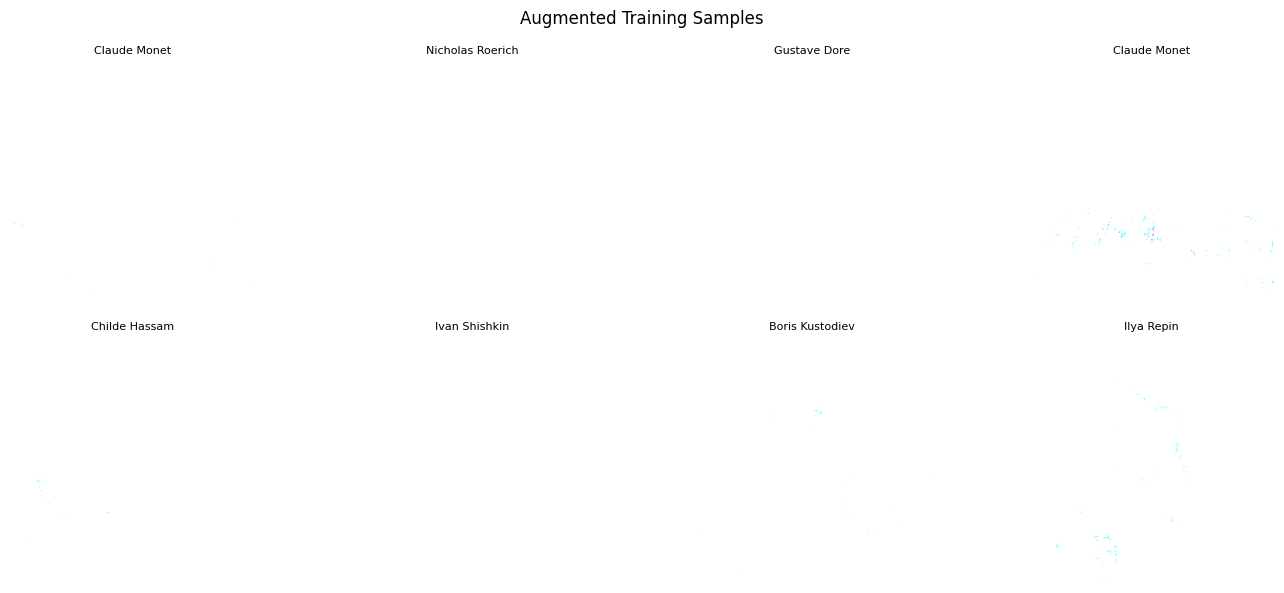

In [14]:
# Visualise a batch of augmented training samples
sample_imgs, sample_labels = next(iter(train_ds))
sample_display = np.clip((sample_imgs[:8].numpy() + 1.0) / 2.0, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels[:8]):
    ax.imshow(img)
    ax.set_title(class_names[np.argmax(lbl)].replace('_', ' '), fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Model Architecture

```
Input (224x224x3)
  -> EfficientNetB0 backbone (pretrained, frozen in Phase 1)
       -> GlobalAveragePooling2D
            -> BatchNormalization
                 -> Dense(512, relu) + Dropout(0.4)
                      -> Dense(256, relu) + Dropout(0.3)
                           -> Dense(23, softmax)
```

In [15]:
def build_model(freeze_base=True):
    """Build EfficientNetB0 transfer learning model."""
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = not freeze_base

    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(512, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(256, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(freeze_base=True)

total_params = model.count_params()
trainable_p1 = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total parameters   : {total_params:,}')
print(f'Trainable (Phase 1): {trainable_p1:,}')
model.summary(expand_nested=False)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters   : 4,847,802
Trainable (Phase 1): 795,671


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,847,802 (18.49 MB)

 Trainable params: 795,671 (3.04 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

---
## 3. Phase 1 — Feature Extraction (frozen backbone)

In [16]:
def make_metrics():
    return [
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=make_metrics()
)

cb_early = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
cb_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    'best_phase1.weights.h5', monitor='val_loss',
    save_best_only=True, save_weights_only=True, verbose=0
)

class LRLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        if logs is not None:
            logs['lr'] = lr

cb_lr = LRLogger()



In [17]:
history1 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=[cb_early, cb_reduce, cb_ckpt, cb_lr],
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 929s 3s/step - accuracy: 0.4638 - loss: 2.0111 - top3_accuracy: 0.6854 - val_accuracy: 0.6327 - val_loss: 1.3916 - val_top3_accuracy: 0.8276 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 925s 3s/step - accuracy: 0.6197 - loss: 1.4081 - top3_accuracy: 0.8273 - val_accuracy: 0.6867 - val_loss: 1.2013 - val_top3_accuracy: 0.8626 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 969s 3s/step - accuracy: 0.6822 - loss: 1.2010 - top3_accuracy: 0.8699 - val_accuracy: 0.6952 - val_loss: 1.1939 - val_top3_accuracy: 0.8666 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 906s 3s/step - accuracy: 0.7163 - loss: 1.0766 - top3_accuracy: 0.8960 - val_accuracy: 0.7181 - val_loss: 1.1371 - val_top3_accuracy: 0.8811 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 906s 3s/step - accuracy: 0.7480 - loss: 1.0022 - top3_accuracy: 0.9126 - val_accuracy: 0

In [1]:
def plot_history(history, title='Training History', offset=0):
    h = history.history
    n = len(h['accuracy'])
    epochs = range(offset + 1, offset + n + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Loss ────────────────────────────────────────────────────
    axes[0].plot(epochs, h['loss'],     label='Train loss')
    axes[0].plot(epochs, h['val_loss'], label='Val loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # ── Accuracy ─────────────────────────────────────────────────
    axes[1].plot(epochs, h['accuracy'],     label='Train acc')
    axes[1].plot(epochs, h['val_accuracy'], label='Val acc')
    if 'val_top3_accuracy' in h:
        axes[1].plot(epochs, h['val_top3_accuracy'],
                     label='Val top-3', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # ── Overfitting gap ──────────────────────────────────────────
    gap = [tr - va for tr, va in zip(h['accuracy'], h['val_accuracy'])]
    axes[2].plot(epochs, gap, color='tomato', label='Train − Val acc')
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[2].fill_between(epochs, gap, 0,
                          where=[g > 0 for g in gap],
                          alpha=0.15, color='tomato', label='Overfit zone')
    axes[2].set_title('Overfitting Gap')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy Gap')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history1, title='Phase 1 — Feature Extraction')

NameError: name 'history1' is not defined

---
## 4. Phase 2 — Fine-tuning (unfreeze top layers)

Unfreeze the **top 30 layers** of EfficientNetB0 and train at **10x smaller learning rate** (1e-4).

In [ ]:
# Load best Phase-1 weights, then unfreeze top layers
model.load_weights('best_phase1.weights.h5')

base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Backbone total layers : {len(base_model.layers)}')
print(f'Fine-tuning from layer: {fine_tune_from}')
print(f'Trainable (Phase 2)   : {trainable_p2:,}')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=make_metrics()
)

cb_early2 = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
cb_reduce2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1
)
cb_ckpt2 = callbacks.ModelCheckpoint(
    'best_final.weights.h5', monitor='val_loss',
    save_best_only=True, save_weights_only=True, verbose=0
)
cb_lr2 = LRLogger()

history2 = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[cb_early2, cb_reduce2, cb_ckpt2, cb_lr2],
    verbose=1
)

In [ ]:
plot_history(history2, title='Phase 2 — Fine-tuning',
             offset=len(history1.history['accuracy']))

In [ ]:
# Combined training curve (Phase 1 + Phase 2)
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

combined = combine_histories(history1, history2)
phase1_end = len(history1.history['accuracy'])
total_epochs = len(combined['accuracy'])
epochs_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, val_key, title in [
    (axes[0], 'loss',     'val_loss',     'Loss'),
    (axes[1], 'accuracy', 'val_accuracy', 'Accuracy'),
]:
    ax.plot(epochs_range, combined[key],     label='Train')
    ax.plot(epochs_range, combined[val_key], label='Val')
    ax.axvline(phase1_end, color='gray', linestyle=':', label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

# Gap subplot
gap = [tr - va for tr, va in zip(combined['accuracy'], combined['val_accuracy'])]
axes[2].plot(epochs_range, gap, color='tomato', label='Train − Val acc')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].fill_between(epochs_range, gap, 0,
                      where=[g > 0 for g in gap],
                      alpha=0.15, color='tomato')
axes[2].axvline(phase1_end, color='gray', linestyle=':', label='Fine-tune start')
axes[2].set_title('Overfitting Gap'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

---
## 5. Evaluation on Test Set

In [ ]:
# Load best fine-tuned weights for final evaluation
model.load_weights('best_final.weights.h5')

test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=1)
print(f'\nTest  Loss     : {test_loss:.4f}')
print(f'Test  Top-1 Acc: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test  Top-3 Acc: {test_top3:.4f}  ({test_top3*100:.2f}%)')

### Test-Time Augmentation (TTA)

In [ ]:
TTA_STEPS = 10

tta_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomBrightness(factor=0.08),
], name='tta_aug')

def apply_tta(img, label):
    img = tta_aug(img, training=True)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = keras.applications.efficientnet.preprocess_input(img)
    return img, label

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds_raw])
n_test = len(y_true)

print(f'Running TTA with {TTA_STEPS} passes...')
tta_probs = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
for step in range(TTA_STEPS):
    tta_ds = test_ds_raw.map(apply_tta, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    tta_probs += model.predict(tta_ds, verbose=0)
    print(f'  Step {step + 1}/{TTA_STEPS}')
tta_probs /= TTA_STEPS

y_pred_standard = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_pred_tta      = np.argmax(tta_probs, axis=1)

acc_std = (y_pred_standard == y_true).mean()
acc_tta = (y_pred_tta      == y_true).mean()
print(f'Standard accuracy : {acc_std:.4f} ({acc_std * 100:.2f}%)')
print(f'TTA accuracy      : {acc_tta:.4f} ({acc_tta * 100:.2f}%)')
print(f'TTA improvement   : {(acc_tta - acc_std) * 100:+.2f}%')

y_pred_probs = tta_probs
y_pred       = y_pred_tta

### Classification Report & Confusion Matrix

In [ ]:
# Per-class classification report
artist_names_short = [n.replace('_', ' ') for n in class_names]
report = classification_report(y_true, y_pred, target_names=artist_names_short, digits=3)
print('Classification Report')
print('=' * 60)
print(report)

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=artist_names_short,
    yticklabels=artist_names_short,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Artist', fontsize=12)
ax.set_ylabel('True Artist', fontsize=12)
ax.set_title('Normalised Confusion Matrix (row = true class)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class F1 bar chart
f1_per_class = f1_score(y_true, y_pred, average=None)

order = np.argsort(f1_per_class)
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d73027' if f < 0.5 else '#4575b4' for f in f1_per_class[order]]
bars = ax.barh([artist_names_short[i] for i in order], f1_per_class[order], color=colors)
ax.axvline(np.mean(f1_per_class), color='black', linestyle='--',
           label=f'Macro F1: {np.mean(f1_per_class):.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Per-class F1 Score on Test Set')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Macro F1    : {macro_f1:.4f}')
print(f'Weighted F1 : {weighted_f1:.4f}')

### Error Analysis — Misclassified Examples

In [ ]:
# Show misclassified images with true vs predicted labels
test_file_paths = np.array(test_ds_raw.file_paths)

wrong_mask  = y_pred != y_true
wrong_paths = test_file_paths[wrong_mask]
wrong_true  = y_true[wrong_mask]
wrong_pred  = y_pred[wrong_mask]
wrong_conf  = y_pred_probs[wrong_mask].max(axis=1)

# Pick 12 high-confidence mistakes
high_conf_idx = np.argsort(wrong_conf)[::-1][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, idx in zip(axes.flatten(), high_conf_idx):
    img = mpimg.imread(wrong_paths[idx])
    true_name = class_names[wrong_true[idx]].replace('_', ' ')
    pred_name = class_names[wrong_pred[idx]].replace('_', ' ')
    conf      = wrong_conf[idx]
    ax.imshow(img)
    ax.set_title(f'True: {true_name} Pred: {pred_name} ({conf:.2f})',
                 fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('High-Confidence Misclassifications', fontsize=13)
plt.tight_layout()
plt.show()

### Grad-CAM — Where Does the Model Look?

In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    """Generate a Grad-CAM heatmap for the given image."""
    backbone = model.get_layer(base_model.name)
    last_conv_name = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, keras.layers.Conv2D):
            last_conv_name = layer.name
            break

    grad_model = keras.Model(
        inputs=model.input,
        outputs=[
            backbone.get_layer(last_conv_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(tf.argmax(predictions[0]))


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on the original image."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colormap        = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colormap        = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(alpha * colormap + (1 - alpha) * img)
    return img, superimposed


def preprocess_single_image(img_path):
    """Load and preprocess a single image for the model."""
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    return img_array


# Generate Grad-CAM visualisations — 2 correctly classified per artist
N_PER_ARTIST = 2
correct_mask = y_pred == y_true

artist_examples = {cls: [] for cls in range(NUM_CLASSES)}
for i in range(len(y_true)):
    if correct_mask[i] and len(artist_examples[y_true[i]]) < N_PER_ARTIST:
        artist_examples[y_true[i]].append(test_file_paths[i])

n_artists = len(class_names)
fig, axes = plt.subplots(n_artists, 3 * N_PER_ARTIST,
                         figsize=(5 * N_PER_ARTIST * 3, n_artists * 2.5))

for row, cls_idx in enumerate(range(n_artists)):
    for ex_i, img_path in enumerate(artist_examples[cls_idx]):
        img_tensor = preprocess_single_image(img_path)
        heatmap, pred_cls = make_gradcam_heatmap(img_tensor, model)
        original, overlay = overlay_gradcam(img_path, heatmap)

        col_base = ex_i * 3

        axes[row, col_base].imshow(original)
        if row == 0:
            axes[row, col_base].set_title('Original', fontsize=8)
        axes[row, col_base].axis('off')

        hm_resized = cv2.resize(heatmap, IMG_SIZE)
        axes[row, col_base + 1].imshow(hm_resized, cmap='jet')
        if row == 0:
            axes[row, col_base + 1].set_title('Grad-CAM', fontsize=8)
        axes[row, col_base + 1].axis('off')

        axes[row, col_base + 2].imshow(overlay)
        if row == 0:
            axes[row, col_base + 2].set_title('Overlay', fontsize=8)
        axes[row, col_base + 2].axis('off')

    axes[row, 0].set_ylabel(class_names[cls_idx].replace('_', '\n'),
                            fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Grad-CAM Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Attention distribution analysis — border vs center
print('\n-- Attention Distribution Analysis --')
print('Checking if activation is concentrated in borders (possible signature)\n')

border_ratios = {cls: [] for cls in class_names}

for cls_idx in range(n_artists):
    for img_path in artist_examples[cls_idx]:
        img_tensor = preprocess_single_image(img_path)
        heatmap, _ = make_gradcam_heatmap(img_tensor, model)
        hm = cv2.resize(heatmap, IMG_SIZE)

        h, w = hm.shape
        margin_h, margin_w = int(h * 0.15), int(w * 0.15)

        border_mask = np.zeros_like(hm, dtype=bool)
        border_mask[:margin_h, :] = True
        border_mask[-margin_h:, :] = True
        border_mask[:, :margin_w] = True
        border_mask[:, -margin_w:] = True

        total_activation = hm.sum()
        if total_activation > 0:
            border_ratio = hm[border_mask].sum() / total_activation
        else:
            border_ratio = 0.0
        border_ratios[class_names[cls_idx]].append(border_ratio)

print(f'{"Artist":<30} {"Border %":>10} {"Center %":>10}  Interpretation')
print('-' * 75)
for cls in class_names:
    mean_border = np.mean(border_ratios[cls]) * 100
    mean_center = 100 - mean_border
    flag = 'possible signature bias' if mean_border > 55 else 'style-focused'
    print(f'{cls.replace("_", " "):<30} {mean_border:>9.1f}% {mean_center:>9.1f}%  {flag}')

---
## 6. Final Summary

In [ ]:
n_train = len(train_ds_raw.file_paths)
n_val   = sum(len(list(d.iterdir())) for d in val_dir.iterdir())

print('=' * 50)
print('        FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  Test Top-1 Accuracy : {test_acc*100:.2f}%')
print(f'  Test Top-3 Accuracy : {test_top3*100:.2f}%')
print(f'  Macro F1            : {macro_f1:.4f}')
print(f'  Weighted F1         : {weighted_f1:.4f}')
print(f'  Test Loss           : {test_loss:.4f}')
print('=' * 50)
print(f'  Architecture        : EfficientNetB0 + custom head')
print(f'  Total parameters    : {total_params:,}')
print(f'  Classes             : {NUM_CLASSES}')
print(f'  Train / Val / Test  : {n_train} / {n_val} / {n_test}')
print('=' * 50)

---
## 7. Save Weights to Google Drive

In [ ]:
import shutil

save_dir = Path('/content/drive/MyDrive/wikiart_weights')
save_dir.mkdir(parents=True, exist_ok=True)

for f in ['best_phase1.weights.h5', 'best_final.weights.h5']:
    if Path(f).exists():
        shutil.copy2(f, save_dir / f)
        print(f'Saved {f} -> {save_dir / f}')

print('Done!')